#Damped Harmonic Oscillators

Oscillatory motion is a fundamental phenomenon observed in all parts of nature. It is seen in many parts of real-world Physics like vibrations of atoms, foundations of Quantum field theory, swinging of objects like block-mass system or pendulum. The periodic motion which is sustained by a restoring force is influenced by a damping term and the behavior changes drastically. They are chiefly goverened by ordinary differential equations (ODE).

$$m \frac{d^2x}{dz} + b \frac{dx}{dz} + kx = 0.$$

here b is the damping constant and the damping term is directly proportional to the first derivative of x.

Because of the damping term, the oscillations decay over time and the system comes to rest.

ODEs are solved analytically by Euler method (simplest way), Runge-Kutta (more accurate) methods int which the next step is the weighted average of slopes. It is the standard for solving ODE. However a variation of neural network was discovered to evidently solve the Differential equations by obeying the physics behind them- **Physics Informed Neural Networks**

##Physics Informed Neural Networks

They are a specialized form of neural networks in which the loss terms are modified to obey the physics behind the differential equations. So, the universal function approximator is "informed" about physics by introducing the ODE into the loss function. Basically, we add a differential equation residual term to the loss function.

$$Loss = \text{MSE}_{\text{initial\_conditions}} + \text{MSE}_{\text{ODE\_residual}}$$

The damped harmonic oscillator here is solved with the help of PINN.

For a specified value of damping ratio, the Neural Network is trained for different values of z and the output is the position (x).

The loss function consists of the ODE residual loss + the boundary condition loss.

The Neural Network must strictly follow the boundary conditions (here the boundary conditions are given x₀ = 0.7 and v₀ = 1.2)

The losses are:

$$MSE_{ODE} = \frac{1}{N_f} \sum |x_{zz} + 2\xi x_z + x|^2$$

$$MSE_{x0} = \frac{1}{N_{ic}} \sum |x(0, \xi) - 0.7|^2$$

$$MSE_{v0} = \frac{1}{N_{ic}} \sum |x_z(0, \xi) - 1.2|^2$$

$Loss = MSE_{ODE} + \lambda_1 MSE_{x0} + \lambda_2 MSE_{v0}$

we assume $\lambda_1$ and $\lambda_2$ equal to 1 for now, but for complex problems, these weights are needed to be tuned to work optimally.


since we have to condition the neural network on damping ratios in the range ξ = 0.1 to 0.4, the damping ratio is added to the input itself for the neural network to learn the mapping of different damping ratios and z against the position x.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import qmc
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [3]:
torch.manual_seed(34)
np.random.seed(34)
#for reproducability

In [4]:
#selecting the device (I am using the google colab runtime environment!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")

Using device : cuda


Two set of data are created: the **collocation points** (where the residual is calculated) and **initial condition points** (where the boundary conditions are enforced).

I used Sobol Sequences for sampling the collocation points, it is a "Quasi-Monte Carlo" QMC method that fill spaces as uniformly as possible. The number of points need to be power of 2. (although, simpler methods, like uniform grid,  could be used here for the data generation since it is a simple domain, but Sobol is used often in industry standards)

For the initial conditions, I used LatinHypercube LHS which is a stratified sampling technique. (just for fun, this was not needed)

The idea was taken from [1].

In [17]:
# data generation
def generate_data_scaled(N_f=20000, N_ic=800, device=None, scale_input=False):
  """
  generates collocation points and initial condition points using Sobol and LHC respectively.
  z in the range [0,20] and
  zeta in the range [0.1, 0.4]
  """
  if device is None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  m = int(np.floor(np.log2(N_f)))
  N_f_sobol = 2 ** m # adjusting N_f to nearest power of 2, which is required for Sobol

  #the collocation points, z in [0,20], zeta in [0.1, 0.4]

  sampler_f = qmc.Sobol(d=2, scramble=True)
  sample_f = sampler_f.random_base2(m=m)



  t_f = sample_f[:, 0:1]

  t_f = t_f if scale_input else (t_f * 20)


  zeta_f = sample_f[:, 1:2] * 0.3 + 0.1
  #the initial condition points at t=0, zeta in [0.1, 0.4]

  sampler_ic = qmc.LatinHypercube(d=1)
  sample_ic = sampler_ic.random(n=N_ic)

  t_ic = np.zeros((N_ic, 1))
  zeta_ic = sample_ic[:, 0:1] * 0.3 + 0.1

  t_f_tensor = torch.tensor(t_f, dtype=torch.float32, device=device, requires_grad=True)
  zeta_f_tensor = torch.tensor(zeta_f, dtype=torch.float32, device=device)
  t_ic_tensor = torch.tensor(t_ic, dtype=torch.float32, device=device, requires_grad=True)
  zeta_ic_tensor = torch.tensor(zeta_ic, dtype=torch.float32, device=device)

  return t_f_tensor, zeta_f_tensor, t_ic_tensor, zeta_ic_tensor

In [6]:
def ode_residual(model, t, zeta):
  """this returns the ODE residual of the neural network's output"""
    x = model(t, zeta)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

    return x_tt + 2.0 * zeta * x_t + x

In [7]:
def ic_losses(model, t_ic, zeta_ic, x0=0.7, v0_z=1.2):
  """returns the loss over the boundary conditions"""
    v0_t = v0_z

    x_ic = model(t_ic, zeta_ic)

    x_t_ic = torch.autograd.grad(x_ic, t_ic, grad_outputs=torch.ones_like(x_ic), create_graph=True)[0]
    loss_x0 = torch.mean((x_ic - x0) ** 2)
    loss_v0 = torch.mean((x_t_ic - v0_t) ** 2)

    return loss_x0, loss_v0

three hidden layers each of dimension (128, 128)

**ReLU** is not used as it's second derivative is zero

In [8]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=128):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t, xi):
        return self.net(torch.cat([t, xi], dim=1))

the Adam + L-BFGS Strategy is used for training. Adam first gets close to the solution then L-BFGS is switched on to "polish" the solution and converge rapidly to the exact minimum.

**L-BFGS** is often used in PINN training due to its exceptional performance in minimizing loss in smooth loss curves as seen in physics problems. It is highly precise. It is limited memeory BFGS, it uses history of last few gradients to mimic the curvature and find the optimal distance.

In [11]:
def train_pinn(adam_epochs=30000, lbfgs_max_iter=10000, lambda1=1.0, lambda2=1.0, N_f=20000, N_ic=800, device=None):
  """ Adam+ L-BFGS , first 30000 epochs of Adam followed by L-BFGS """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PINN(hidden_dim=128).to(device)
    t_f, zeta_f, t_ic, zeta_ic = generate_data_scaled(N_f=N_f, N_ic=N_ic, device=device, scale_input=False)

    history = {"total": [], "ode": [], "ic_x0": [], "ic_v0": []}

    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(adam_epochs):
        adam.zero_grad()
        ode_res = ode_residual(model, t_f, zeta_f)

        loss_ode = torch.mean(ode_res ** 2)
        loss_x0, loss_v0 = ic_losses(model, t_ic, zeta_ic)

        total_loss = loss_ode + lambda1 * loss_x0 + lambda2 * loss_v0 # the weights of the BC needs to be tuned, I am assuming lambdas = 1 here!

        total_loss.backward()
        adam.step()

        history["total"].append(total_loss.item())
        history["ode"].append(loss_ode.item())
        history["ic_x0"].append(loss_x0.item())
        history["ic_v0"].append(loss_v0.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch} , Total={total_loss.item():.10f}, ODE={loss_ode.item():.10f}, IC(x0)={loss_x0.item():.10f}, IC(v0)={loss_v0.item():.10f}")

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=lbfgs_max_iter,
        max_eval=lbfgs_max_iter,
        history_size=50,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        line_search_fn="strong_wolfe",
    )

    lbfgs_step = [0]

    def closure():
        lbfgs.zero_grad()

        ode_res = ode_residual(model, t_f, zeta_f)
        loss_ode = torch.mean(ode_res ** 2)

        loss_x0, loss_v0 = ic_losses(model, t_ic, zeta_ic)

        total_loss = loss_ode + lambda1 * loss_x0 + lambda2 * loss_v0
        total_loss.backward()

        if lbfgs_step[0] % 100 == 0:
            print(f"LBFGS Step {lbfgs_step[0]}, Total={total_loss.item():.10f}, ODE={loss_ode.item():.10f}, IC(x0)={loss_x0.item():.10f}, IC(v0)={loss_v0.item():.10f}")
        lbfgs_step[0] += 1
        return total_loss

    lbfgs.step(closure)

    # Final diagnostics (with graph for derivative available)
    loss_ode = torch.mean(ode_residual(model, t_f, zeta_f) ** 2)
    loss_x0, loss_v0 = ic_losses(model, t_ic, zeta_ic)
    final_total = loss_ode + lambda1 * loss_x0 + lambda2 * loss_v0

    print(f"[FINAL] Total={final_total.item():.10f}, ODE={loss_ode.item():.10f}, IC(x0)={loss_x0.item():.10f}, IC(v0)={loss_v0.item():.10f}")
    return model, history


In [18]:
#training the PINN for the original ODE
config = dict(adam_epochs=30000, lbfgs_max_iter=10000, N_f=20000, N_ic=800)
model, history = train_pinn(device=device, **config)

Epoch 0 , Total=1.7966008186, ODE=0.0061460435, IC(x0)=0.3776091039, IC(v0)=1.4128457308
Epoch 500 , Total=0.0076684933, ODE=0.0076081213, IC(x0)=0.0000223709, IC(v0)=0.0000380014
Epoch 1000 , Total=0.0059446078, ODE=0.0059035886, IC(x0)=0.0000134840, IC(v0)=0.0000275349
Epoch 1500 , Total=0.0064557847, ODE=0.0054424265, IC(x0)=0.0009968432, IC(v0)=0.0000165153
Epoch 2000 , Total=0.0099683395, ODE=0.0076076463, IC(x0)=0.0017973632, IC(v0)=0.0005633298
Epoch 2500 , Total=0.0042488114, ODE=0.0036962624, IC(x0)=0.0004313433, IC(v0)=0.0001212055
Epoch 3000 , Total=0.0026584982, ODE=0.0025155740, IC(x0)=0.0001170622, IC(v0)=0.0000258621
Epoch 3500 , Total=0.0030957873, ODE=0.0026755044, IC(x0)=0.0001581844, IC(v0)=0.0002620984
Epoch 4000 , Total=0.0019644857, ODE=0.0019457334, IC(x0)=0.0000047915, IC(v0)=0.0000139607
Epoch 4500 , Total=0.0017104084, ODE=0.0016950094, IC(x0)=0.0000034785, IC(v0)=0.0000119204
Epoch 5000 , Total=0.0013860670, ODE=0.0013730726, IC(x0)=0.0000022668, IC(v0)=0.000

solve_ivp (from scipy) is used as ground truth for our PINN. it uses numerical integration to step through time. Here, Runge-Kutta (RK45) is used as basic step and an adaptive part to keep the time step in control, wihtin a tolerance range.

They can be as accurate upto ~$10^{-12}$. Hence I used for ground truth for our Neural Network. Our neural network could be trained further to be more accurate here. But training on few data points (20K) and few epochs (30K for adam and ~2-10K L-BFGS) the neural network is able to achieve the total MSE in the range of ~$10^{-7}$ which is appreciable.

Here is the plot of out predictions vs the solve_ivp solution.

In [19]:
def solve_ivp_ground_truth(z_values, zeta_values, x0=0.7, v0=1.2):
    """Ground truth in original z-domain using SciPy solve_ivp."""
    truth = np.zeros((len(zeta_values), len(z_values)), dtype=np.float64)

    for i, zeta in enumerate(zeta_values):
        def ode_system(z, y):
            # y = [x, dx/dz]
            return [y[1], -2.0 * zeta * y[1] - y[0]]

        sol = solve_ivp(
            ode_system,
            (z_values[0], z_values[-1]),
            [x0, v0],
            t_eval=z_values,
            method="RK45",
            rtol=1e-9,
            atol=1e-11,
        )

        if not sol.success:
            raise RuntimeError(f"solve_ivp failed for xi={zeta}: {sol.message}")

        truth[i, :] = sol.y[0, :]

    return truth


def plot_model_vs_solve_ivp(model, zeta_values=(0.1, 0.25, 0.4), z_min=0.0, z_max=20.0, n_points=500, x0=0.7, v0=1.2):
    """
    Compare a trained PINN against solve_ivp ground truth for selected zeta values.
    """
    model.eval()
    device = next(model.parameters()).device

    # a plotting grid in original z-domain, which is [0, 20]
    z_plot = np.linspace(z_min, z_max, n_points).reshape(-1, 1)

    # Ground truth from solve_ivp (shape: [len(zeta_values), len(z_plot)])

    zeta_array = np.array(zeta_values, dtype=np.float64)
    truth = solve_ivp_ground_truth(z_plot.flatten(), zeta_array, x0=x0, v0=v0)

    # Plotting predictions vs ground truth
    plt.figure(figsize=(12, 6))
    colors = ["#FF5733", "#33AA55", "#3357FF"]

    for i, zeta_val in enumerate(zeta_values):
        # Prepare model inputs
        model_time = z_plot

        time_tensor = torch.tensor(model_time, dtype=torch.float32, device=device)
        zeta_tensor = torch.full_like(time_tensor, float(zeta_val))

        with torch.no_grad():
            x_pred = model(time_tensor, zeta_tensor).cpu().numpy().reshape(-1)

        # Ground truth curve for this zeta value
        x_true = truth[i, :]

        # Plot
        c = colors[i % len(colors)]
        plt.plot(
            z_plot.flatten(), x_true,
            color=c, linestyle="-", linewidth=2.2,
            label=f"solve_ivp (zeta={zeta_val})"
        )
        plt.plot(
            z_plot.flatten(), x_pred,
            color=c, linestyle="--", linewidth=2.0, dashes=(3, 2),
            label=f"PINN (zeta={zeta_val})"
        )

    plt.title("Vanilla PINN vs solve_ivp: Damped Harmonic Oscillator")
    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.axhline(0.0, color="black", linewidth=0.6, linestyle=":")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


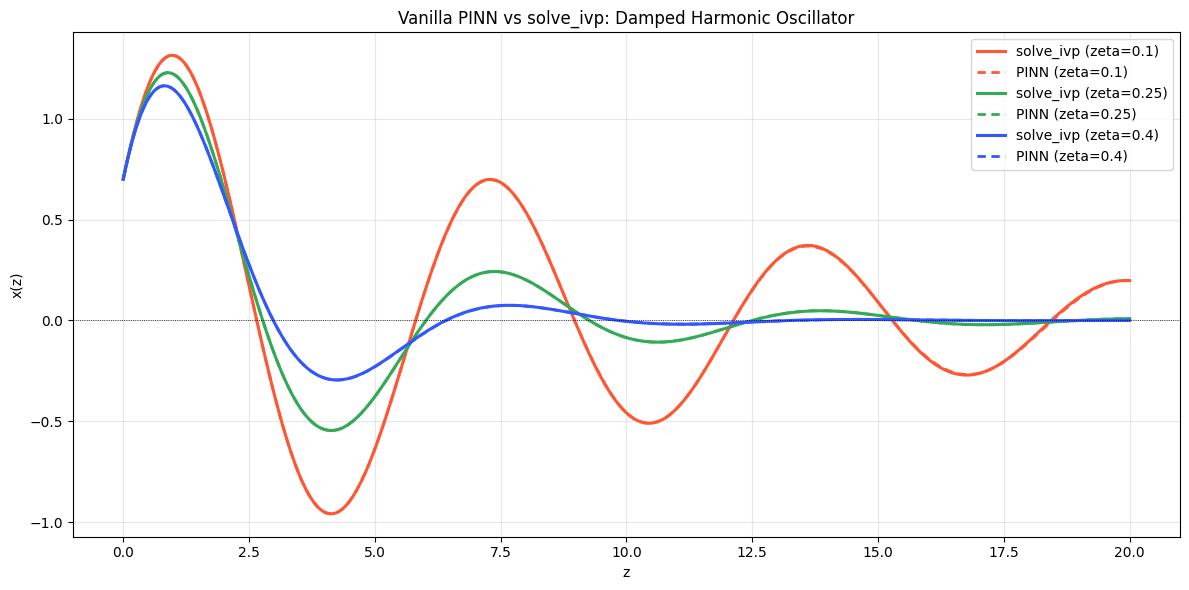

In [20]:
plot_model_vs_solve_ivp(model)

In [28]:
torch.save(model.state_dict(), 'PINN_model_weights.pt')

The above Vanilla PINN can be further optimized for this problem.

An Ansatz is available for this solution which already satisfies the initial conditions exactly in the formula itself, i.e. the neural network need not to care about the initial conditions at all, it is handled by the parent formula which the neural network is part of. Only the residual term is handled by the neural network. This is the HARD- Constrained PINN. The initial connstraints are implemented as hard and fast condition in the form of ansatz.

the ansatz for this problem is:
$$u(t) = u_0 + v_0 t + t^2 N(t; \theta)$$
here, the intial conditions are already satisfied accurately by this equation, hence the neural network focuses only on the ODE residual term or the physics loss term. if we are able to genrate ansatz satisfying problem's boundary conditions then it makes the work easier for neural network, there is no conflict between the ODE and IC losses during optimization.

there is one problem, the $t^2$ term in the ansatz grows very fast for larger domains so we need to scale it down in the range [0,1] to make the training stable.
scaling z from [0,20] to [0,1] transforms the ODE to:
$\frac{1}{20^2} \cdot \frac{d^2x}{dt^2} + 2\xi \cdot \frac{1}{20} \cdot \frac{dx}{dt} + x = 0$

which normalizes to

$\frac{d^2x}{dt^2} + 40\xi \cdot \frac{dx}{dt} + 400x = 0$

Finally, the output equation for the HARD- Constraint PINN is:

$$u(t) = x_0 + 20v_0 t + t^2 N(t; \theta)$$

In [21]:
class Modified_PINN(nn.Module):
    def __init__(self):
      """two hidden layers of dimension (128,128)"""
        super(Modified_PINN, self).__init__()
        self.x0 = 0.7
        self.v0 = 1.2

        self.linear_in = nn.Linear(2, 128)
        self.linear_out = nn.Linear(128, 1)
        self.layers = nn.ModuleList([nn.Linear(128, 128) for _ in range(2)])
        self.act = nn.Tanh()

    def forward(self, t: torch.Tensor, xi: torch.Tensor) -> torch.Tensor:
        out = self.linear_in(torch.cat([t, xi], dim=1))
        out = self.act(out)

        for layer in self.layers:
            out = self.act(layer(out))
        out = self.linear_out(out)

        # Hard-constrained ansatz in scaled domain
        return self.x0 + 20.0 * t * self.v0 + torch.pow(t, 2) * out

In [22]:
def transformed_ode_residual(model, t, zeta):

    # Scaled ODE becomes x'' + 40 * zeta * x' + 400 * x = 0
    x = model(t, zeta)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

    return x_tt + 40.0 * zeta * x_t + 400.0 * x

the training used is similar as above, just the number of iterations are increased to suppress the comparatively large magnitude of loss due to the 400x term.

In [25]:
def train_hard_pinn(adam_epochs=100000, lbfgs_max_iter=2000, N_f=20000, N_ic=500, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = Modified_PINN().to(device)
    t_f, zeta_f, t_ic, zeta_ic = generate_data_scaled(N_f=N_f, N_ic=N_ic, device=device, scale_input=True) # using the same function to generate the data points althought he ic points will be of no use here

    history = {"total": [], "ode": []}

    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    print("Training with HARD constraints")
    for epoch in range(adam_epochs):
        adam.zero_grad()

        ode_res = transformed_ode_residual(model, t_f, zeta_f)
        loss_ode = torch.mean(ode_res ** 2)

        loss_ode.backward() # only the ode loss is backpropagated, since the initial condition losses are always zero

        adam.step()


        history["total"].append(loss_ode.item())
        history["ode"].append(loss_ode.item())

        if epoch % 2000 == 0:
            print(f"Epoch {epoch}, ODE={loss_ode.item():.10f}")

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=lbfgs_max_iter,
        max_eval=lbfgs_max_iter,
        history_size=50,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        line_search_fn="strong_wolfe",
    )

    lbfgs_step = [0]

    def closure():
        lbfgs.zero_grad()
        ode_res = transformed_ode_residual(model, t_f, zeta_f)
        loss_ode = torch.mean(ode_res ** 2)
        loss_ode.backward()

        if lbfgs_step[0] % 200 == 0:
            print(f"LBFGS Step {lbfgs_step[0]}, ODE={loss_ode.item():.10f}")
        lbfgs_step[0] += 1
        return loss_ode

    lbfgs.step(closure)

    loss_ode = torch.mean(transformed_ode_residual(model, t_f, zeta_f) ** 2)

    print(f"FINAL: ODE={loss_ode.item():.10f}")


    return model, history

In [31]:
#training configuration for the HARD - constrained PINN
config = dict(adam_epochs=100000, lbfgs_max_iter = 20000, N_f = 20000, N_ic=500)
hard_model, hard_history = train_hard_pinn(device=device, **config)

Training with HARD constraints
Epoch 0, ODE=35892436.0000000000
Epoch 2000, ODE=711919.9375000000
Epoch 4000, ODE=150451.9062500000
Epoch 6000, ODE=66010.4062500000
Epoch 8000, ODE=30839.8984375000
Epoch 10000, ODE=18490.4335937500
Epoch 12000, ODE=8082.2832031250
Epoch 14000, ODE=5046.0810546875
Epoch 16000, ODE=3431.1149902344
Epoch 18000, ODE=2440.5561523438
Epoch 20000, ODE=1816.0129394531
Epoch 22000, ODE=1389.0615234375
Epoch 24000, ODE=1083.9487304688
Epoch 26000, ODE=861.9882812500
Epoch 28000, ODE=694.7727050781
Epoch 30000, ODE=574.6593627930
Epoch 32000, ODE=563.4742431641
Epoch 34000, ODE=821.2928466797
Epoch 36000, ODE=376.2380981445
Epoch 38000, ODE=326.6289367676
Epoch 40000, ODE=308.5542297363
Epoch 42000, ODE=553.6374511719
Epoch 44000, ODE=240.1202392578
Epoch 46000, ODE=224.6016235352
Epoch 48000, ODE=1083.1943359375
Epoch 50000, ODE=201.5081787109
Epoch 52000, ODE=177.6090545654
Epoch 54000, ODE=167.5738525391
Epoch 56000, ODE=158.5320892334
Epoch 58000, ODE=152.816

In [32]:

def plot_model_vs_solve_ivp(model, zeta_values=(0.1, 0.25, 0.4), z_min=0.0, z_max=20.0, n_points=500, scale_input=True, x0=0.7, v0=1.2):
    """
    Compare a trained PINN against solve_ivp ground truth for selected zeta values.
    """
    model.eval()
    device = next(model.parameters()).device

    # Build plotting grid in original z-domain
    z_plot = np.linspace(z_min, z_max, n_points).reshape(-1, 1)

    # Ground truth from solve_ivp (shape: [len(zeta_values), len(z_plot)])
    zeta_array = np.array(zeta_values, dtype=np.float64)
    truth = solve_ivp_ground_truth(z_plot.flatten(), zeta_array, x0=x0, v0=v0)

    # Plotting the prediction of HARD- Constrained PINN vs the ground truth
    plt.figure(figsize=(12, 6))
    colors = ["#FF5733", "#33AA55", "#3357FF"]

    for i, zeta_val in enumerate(zeta_values):
        # Prepare model inputs
        model_time = (z_plot / 20.0) if scale_input else z_plot

        time_tensor = torch.tensor(model_time, dtype=torch.float32, device=device)
        zeta_tensor = torch.full_like(time_tensor, float(zeta_val))

        with torch.no_grad():
            x_pred = model(time_tensor, zeta_tensor).cpu().numpy().reshape(-1)

        # Ground truth curve for this zeta
        x_true = truth[i, :]

        # Plot
        c = colors[i % len(colors)]
        plt.plot(
            z_plot.flatten(), x_true,
            color=c, linestyle="-", linewidth=2.2,
            label=f"solve_ivp (zeta={zeta_val})"
        )
        plt.plot(
            z_plot.flatten(), x_pred,
            color=c, linestyle="--", linewidth=2.0, dashes=(3, 2),
            label=f"HC PINN (zeta={zeta_val})"
        )

    plt.title("Hard - Constrained PINN vs solve_ivp: Damped Harmonic Oscillator")
    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.axhline(0.0, color="black", linewidth=0.6, linestyle=":")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plotting it agains the solve_ivp solution

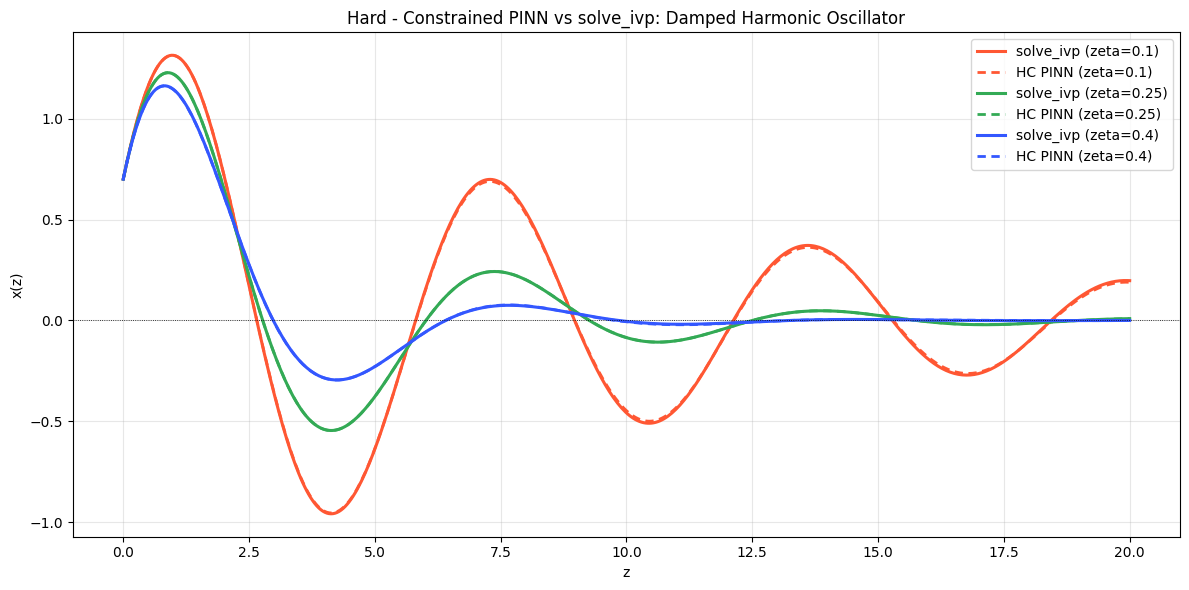

In [33]:
plot_model_vs_solve_ivp(hard_model, scale_input=True)

In [34]:
torch.save(hard_model.state_dict(), 'Hard-Constrained_PINN_model_weights.pt')

This optimization can be used to gain a mathematical edge over the vanilla PINN by already securing the satisfied boundary conditions and it saves us from tuning the weights of the losses used for the boundary conditions.
and, for a Damped Harmonic Oscillator, the mathematical ansatz is almost always superior because the ICs are so simple ($t=0$)
but, we have to manually derive a new ansatz for every different type of boundary condition, so it becomes extremely difficult for complex problems. So the previous method is standard for solving all such kinds of problems.
Also at large domains ($t^2$ seen here) the anstaz grows fast and it can disturb the network's signal.

In [35]:

def predict_on_grid_hard(model, z_values, xi_values, device):
    model.eval()

    XI, Z = np.meshgrid(xi_values, z_values, indexing="ij")

    t_flat = (Z.reshape(-1, 1) / 20.0).astype(np.float32)
    xi_flat = XI.reshape(-1, 1).astype(np.float32)

    with torch.no_grad():

        t_tensor = torch.tensor(t_flat, dtype=torch.float32, device=device)
        xi_tensor = torch.tensor(xi_flat, dtype=torch.float32, device=device)

        pred = model(t_tensor, xi_tensor).cpu().numpy().reshape(len(xi_values), len(z_values))

    return pred


def predict_on_grid_soft(model, z_values, xi_values, device):
    model.eval()

    XI, Z = np.meshgrid(xi_values, z_values, indexing="ij")

    t_flat = (Z.reshape(-1, 1)).astype(np.float32)
    xi_flat = XI.reshape(-1, 1).astype(np.float32)

    with torch.no_grad():

        t_tensor = torch.tensor(t_flat, dtype=torch.float32, device=device)
        xi_tensor = torch.tensor(xi_flat, dtype=torch.float32, device=device)

        pred = model(t_tensor, xi_tensor).cpu().numpy().reshape(len(xi_values), len(z_values))

    return pred


def error_metrics(pred, truth):
    err = pred - truth
    abs_err = np.abs(err)
    return {
        "MAE": float(np.mean(abs_err)),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MaxAbs": float(np.max(abs_err)),
    }, abs_err




In [36]:
# Evaluation grid

z_eval = np.linspace(0.0, 20.0, 300)
xi_eval = np.linspace(0.1, 0.4, 120)

truth_grid = solve_ivp_ground_truth(z_eval, xi_eval)
soft_grid = predict_on_grid_soft(model, z_eval, xi_eval, device)
hard_grid = predict_on_grid_hard(hard_model, z_eval, xi_eval, device)

soft_metrics, soft_abs_err = error_metrics(soft_grid, truth_grid)
hard_metrics, hard_abs_err = error_metrics(hard_grid, truth_grid)

print("\nPerformance Summary vs solve_ivp Ground Truth")
print(f"Soft PINN  MAE: {soft_metrics['MAE']:.10e}, RMSE: {soft_metrics['RMSE']:.10e}, MaxAbs: {soft_metrics['MaxAbs']:.10e}")
print(f"Hard PINN  MAE: {hard_metrics['MAE']:.10e}, RMSE: {hard_metrics['RMSE']:.10e}, MaxAbs: {hard_metrics['MaxAbs']:.10e}")


Performance Summary vs solve_ivp Ground Truth
Soft PINN  MAE: 2.9246691012e-04, RMSE: 4.6374954615e-04, MaxAbs: 5.2859240093e-03
Hard PINN  MAE: 5.9242821704e-04, RMSE: 1.1198855004e-03, MaxAbs: 1.1152270386e-02


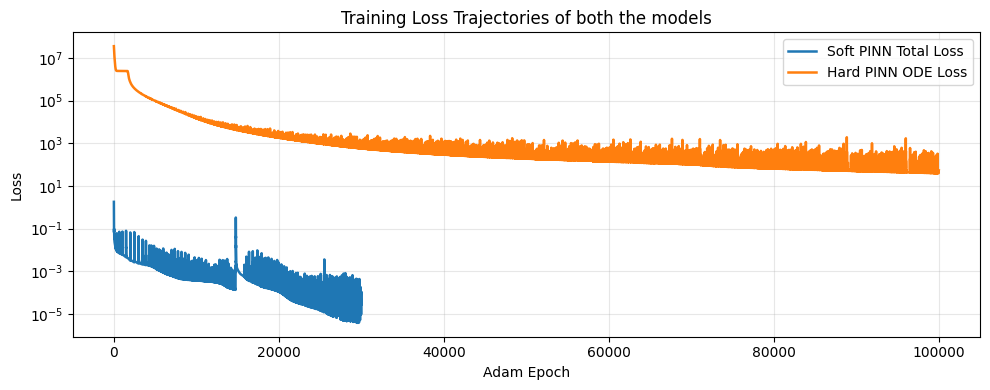

In [40]:
# Training-loss comparison
plt.figure(figsize=(10, 4))
plt.plot(history["total"], label="Soft PINN Total Loss", linewidth=1.8)
plt.plot(hard_history["total"], label="Hard PINN ODE Loss", linewidth=1.8)

plt.yscale("log")

plt.xlabel("Adam Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Trajectories of both the models")

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


this behavior needs to be investigated further!

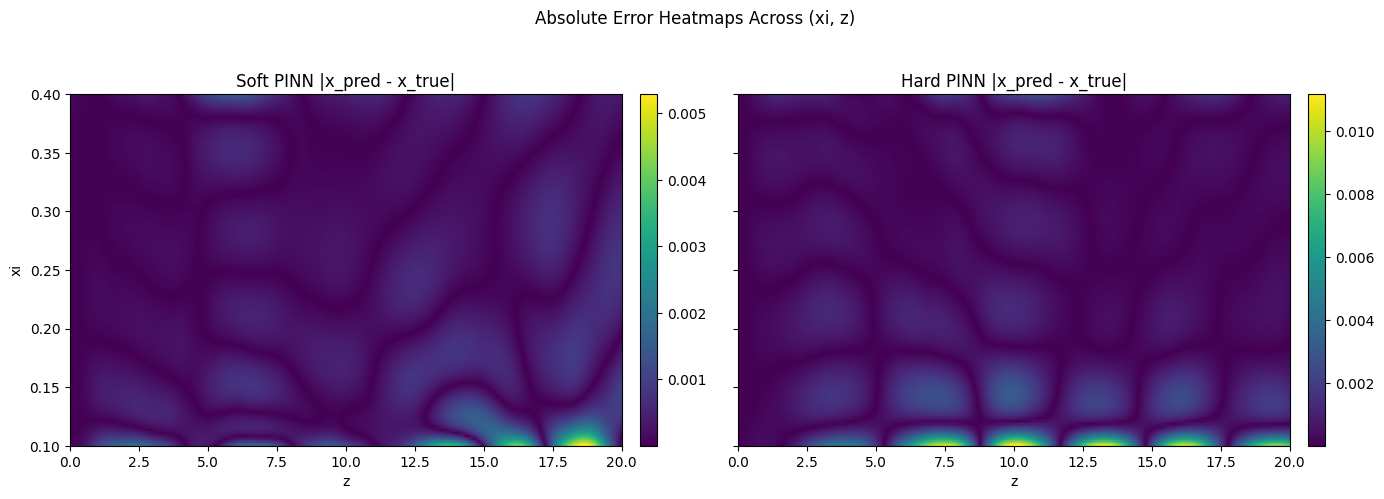

In [39]:
# 2D heatmaps of absolute error over (xi, z)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

im0 = axes[0].imshow(
    soft_abs_err,
    origin="lower",
    aspect="auto",
    extent=[z_eval.min(), z_eval.max(), xi_eval.min(), xi_eval.max()],
    cmap="viridis",
)

axes[0].set_title("Soft PINN |x_pred - x_true|")

axes[0].set_xlabel("z")

axes[0].set_ylabel("xi")

plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(
    hard_abs_err,
    origin="lower",
    aspect="auto",
    extent=[z_eval.min(), z_eval.max(), xi_eval.min(), xi_eval.max()],
    cmap="viridis",
)

axes[1].set_title("Hard PINN |x_pred - x_true|")
axes[1].set_xlabel("z")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

plt.suptitle("Absolute Error Heatmaps Across (xi, z)", y=1.03)
plt.tight_layout()
plt.show()